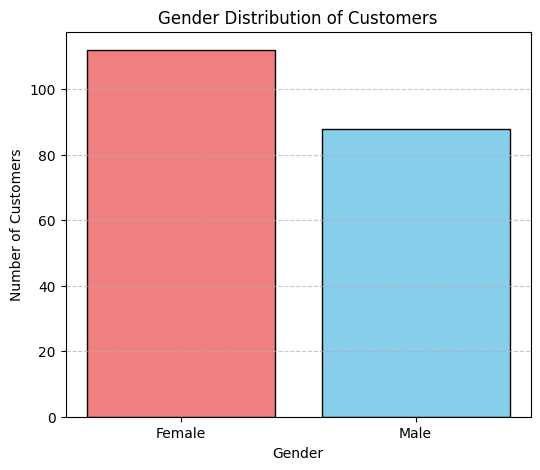

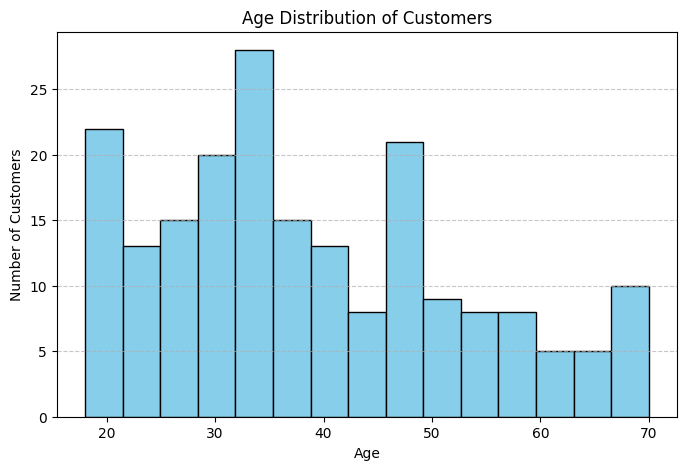

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


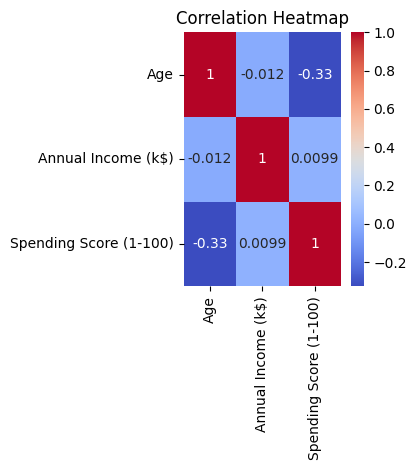

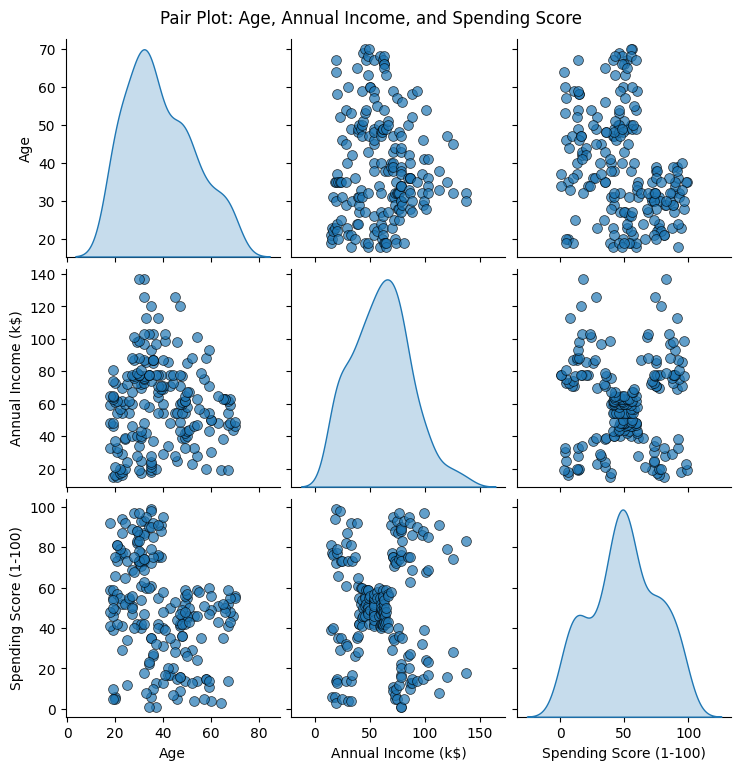

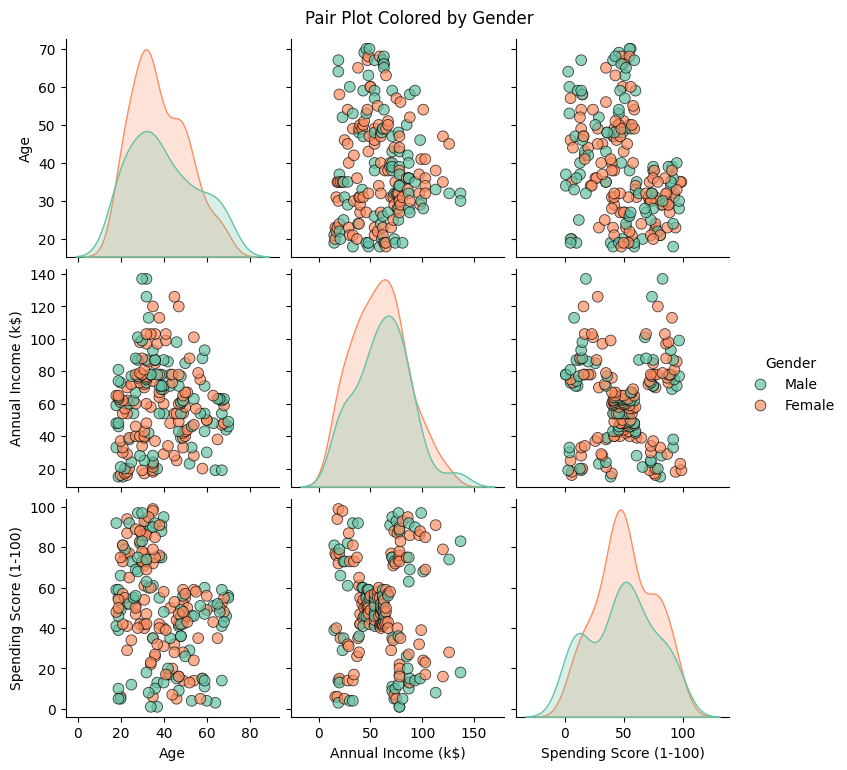


Encoded Gender sample:
    CustomerID  Gender
0           1       1
1           2       1
2           3       0
3           4       0
4           5       0

Scaled feature sample (first 5 rows):
         Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


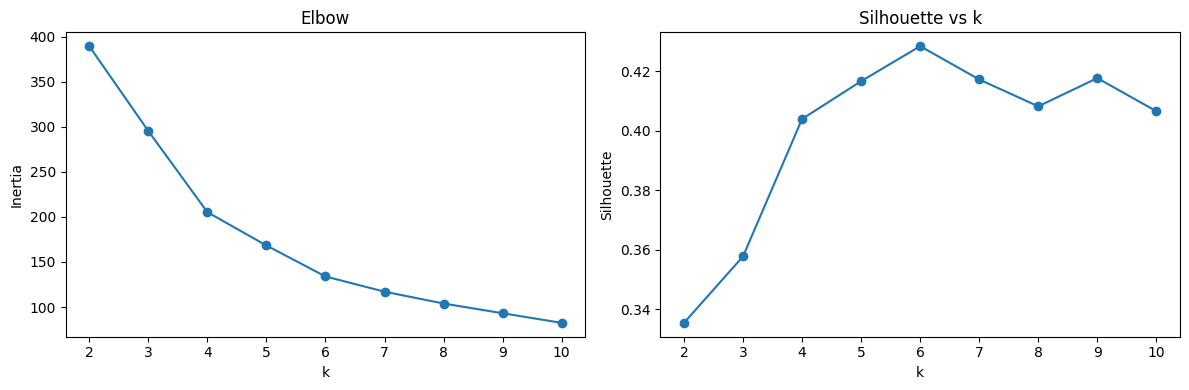

KMeans best k by silhouette: 6 (silhouette=0.4284)

KMeans cluster centers (approx, original scale):
     Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0  56.33               54.27                   49.07        0
1  26.79               57.10                   48.13        1
2  41.94               88.94                   16.97        2
3  32.69               86.54                   82.13        3
4  25.00               25.26                   77.61        4
5  45.52               26.29                   19.38        5


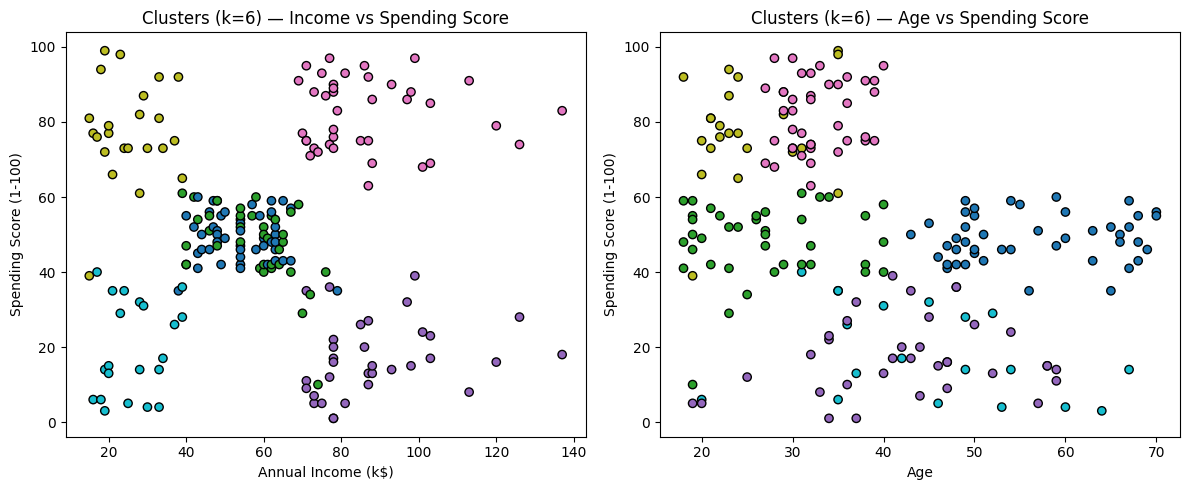


Saved KMeans labelled data -> mall_customers_clusters.csv


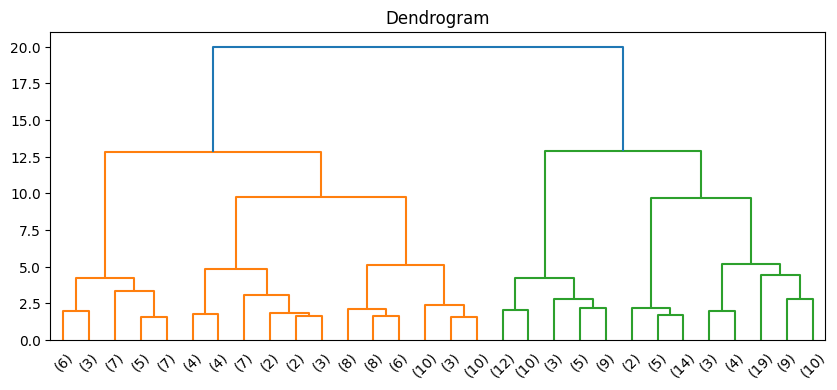


✅ Best k by silhouette score: 6 (Silhouette = 0.4201)
Silhouette scores by k:
  k=2: 0.3180
  k=3: 0.3215
  k=4: 0.3615
  k=5: 0.3900
  k=6: 0.4201
  k=7: 0.3983
  k=8: 0.3665
  k=9: 0.3754
  k=10: 0.3809

Hierarchical cluster counts:
 Cluster_Hier
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64

Hierarchical centers (original scale):
    Cluster_Hier    Age  Annual Income (k$)  Spending Score (1-100)
0             0  27.38               57.51                   45.84
1             1  56.40               55.29                   48.36
2             2  32.69               86.54                   82.13
3             3  43.89               91.29                   16.68
4             4  44.32               25.77                   20.27
5             5  24.81               25.62                   80.24


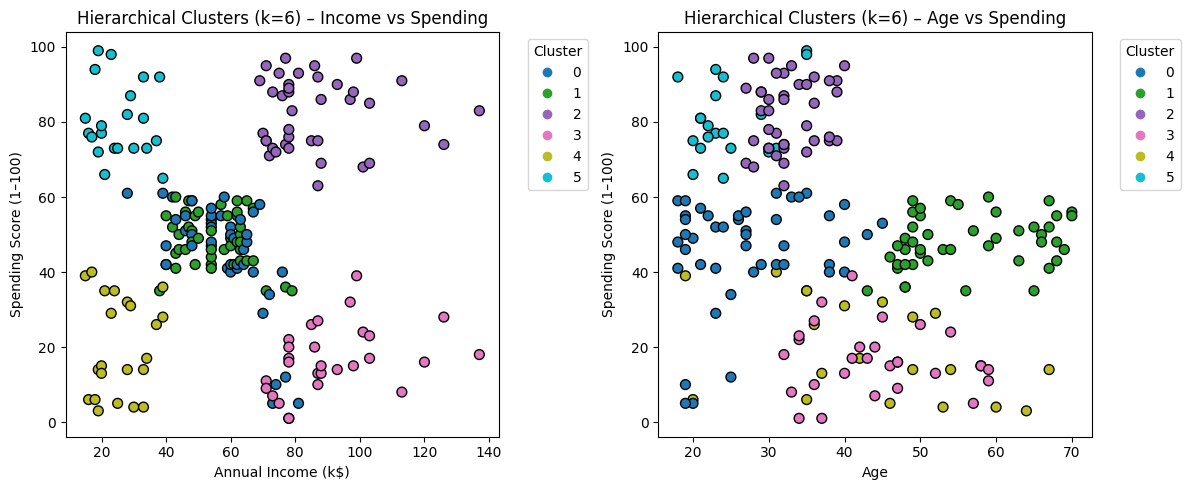


Saved Hierarchical labelled data -> mall_customers_hier_clusters.csv
Columns in K-Means file: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']
 Recreated and saved mall_customers_clusters.csv with Cluster column!
 Merged data successfully!
Columns now: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Cluster_Hier']
Shape: (200, 7)

 Both cluster columns found. Proceeding with comparison...


Adjusted Rand Index (KMeans vs Hier): 0.8914
Silhouette (KMeans): 0.4284, Silhouette (Hier): 0.4201

Contingency table:
 Cluster_Hier   0   1   2   3   4   5
Cluster                             
0              2  43   0   0   0   0
1             39   0   0   0   0   0
2              3   2   0  28   0   0
3              0   0  39   0   0   0
4              1   0   0   0   1  21
5              0   0   0   0  21   0

 Saved comparison summary -> cluster_comparison_summary.csv


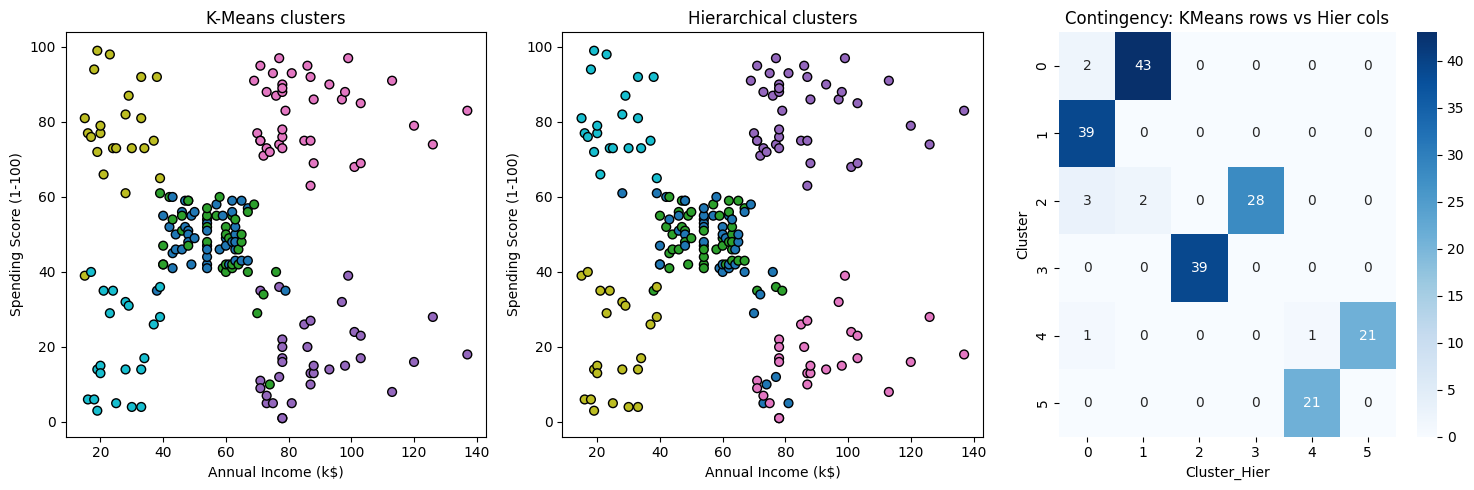

DF columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Cluster_Hier']
Has 'Cluster'?: True
Has 'Cluster_Hier'?: True

First 5 rows:
    CustomerID  Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1  19.0                15.0                    39.0   
1           2       1  21.0                15.0                    81.0   
2           3       0  20.0                16.0                     6.0   
3           4       0  23.0                16.0                    77.0   
4           5       0  31.0                17.0                    40.0   

   Cluster  Cluster_Hier  
0        4             4  
1        4             5  
2        5             4  
3        4             5  
4        5             4  

X already exists with shape: (200, 3)

'Cluster' already exists — no action taken.

'Cluster_Hier' already exists.

Saved dataframe to: mall_customers_clusters_with_labels.csv


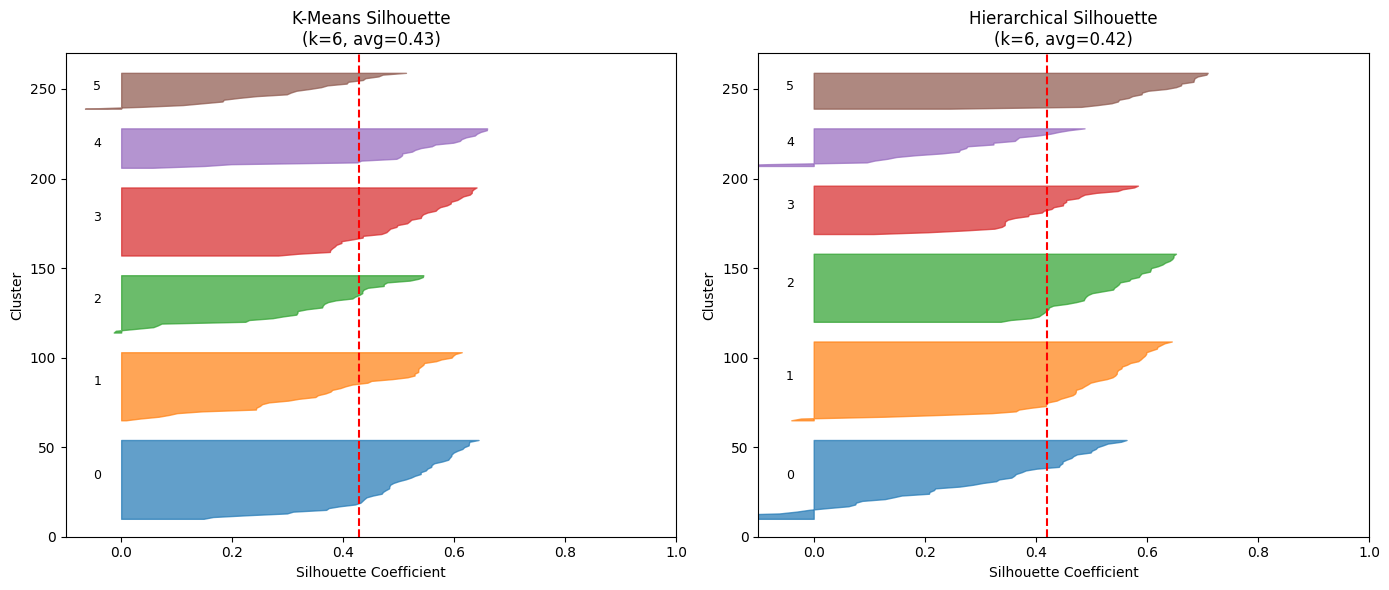

Saved combined silhouette plot to: combined_silhouette_comparison.png
Best k (KMeans): 6 silhouette: 0.4284167762892593
Best k (Hierarchical): 6 silhouette: 0.4201169558789579


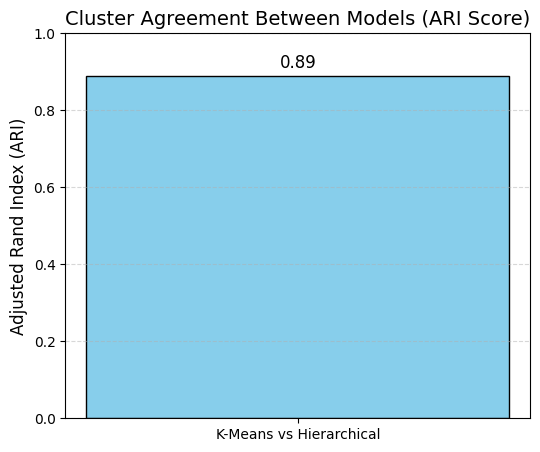

In [6]:
import pandas as pd
mall_customers_df = pd.read_csv("Mall_Customers.csv")
mall_customers_df.head()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

mall_customers_df.shape

mall_customers_df.describe()

import matplotlib.pyplot as plt

# Count the number of customers per gender
gender_counts = mall_customers_df["Gender"].value_counts()

# Create bar chart
plt.figure(figsize=(6, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['lightcoral', 'skyblue'], edgecolor='black')
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

import matplotlib.pyplot as plt

# Create histogram for Age distribution
plt.figure(figsize=(8, 5))
plt.hist(mall_customers_df['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Correlation Matrix
corr_matrix = mall_customers_df.drop('CustomerID', axis=1).select_dtypes(include='number').corr()
print(corr_matrix)

#Correlation heatmap

plt.subplot(1, 2, 2)
sns.heatmap(mall_customers_df.drop('CustomerID', axis=1).select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# Create pair plot for Age, Annual Income, and Spending Score
sns.pairplot(
   mall_customers_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
    diag_kind='kde',   # KDE curve on diagonal for smooth density visualization
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k'}
)

plt.suptitle("Pair Plot: Age, Annual Income, and Spending Score", y=1.02)
plt.show()

sns.pairplot(
   mall_customers_df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
    hue='Gender',              # Color by Gender
    diag_kind='kde',
    palette='Set2',
    plot_kws={'alpha': 0.7, 's': 60, 'edgecolor': 'k'}
)

plt.suptitle("Pair Plot Colored by Gender", y=1.02)
plt.show()

ORIG = "Mall_Customers.csv"
KMEANS_OUT = "mall_customers_clusters.csv"
HIER_OUT = "mall_customers_hier_clusters.csv"
SUMMARY_OUT = "cluster_comparison_summary.csv"

df = mall_customers_df.copy()
df =  mall_customers_df.dropna()

# Encode Gender into numeric (use df, not mall_customers_df)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

print("\nEncoded Gender sample:\n", df[['CustomerID','Gender']].head())

# Define features to use for clustering
features = ['Age','Annual Income (k$)','Spending Score (1-100)']

# Convert to float and scale
df[features] = df[features].astype(float)
scaler = StandardScaler()
X = scaler.fit_transform(df[features].values)   # scaled array used by all clustering

print("\nScaled feature sample (first 5 rows):\n", pd.DataFrame(X, columns=features).head())

# Determine optimal k using Elbow (inertia) and Silhouette score
from sklearn.cluster import KMeans

inertia = []
sil_scores = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Plot Elbow and Silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertia, '-o'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')
plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, '-o'); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

best_k = int(list(K_range)[np.argmax(sil_scores)])
print(f"KMeans best k by silhouette: {best_k} (silhouette={max(sil_scores):.4f})")

# Final KMeans fit
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# show cluster centers in original scale
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=features)
centers_df['Cluster'] = range(best_k)
print("\nKMeans cluster centers (approx, original scale):")
print(centers_df.round(2))

# Visualize clusters in the original feature space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='tab10', edgecolor='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Clusters (k={best_k}) — Income vs Spending Score')

plt.subplot(1, 2, 2)
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='tab10', edgecolor='k')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Clusters (k={best_k}) — Age vs Spending Score')

plt.tight_layout()
plt.show()

# Save results to CSV
df.to_csv(KMEANS_OUT, index=False)
print(f"\nSaved KMeans labelled data -> {KMEANS_OUT}")

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
#Hierarchical clustering
# ---------------------------
# Dendrogram (optional)
Z = linkage(X, method='ward')
plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrogram'); plt.show()

# ---------- Step 6: Find optimal k using silhouette score ----------
silhouette_scores = {}
best_k = None
best_sil = -1

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X)
    sil = silhouette_score(X, labels)
    silhouette_scores[k] = sil
    if sil > best_sil:
        best_k, best_sil = k, sil

print(f"\n✅ Best k by silhouette score: {best_k} (Silhouette = {best_sil:.4f})")
print("Silhouette scores by k:")
for k, s in silhouette_scores.items():
    print(f"  k={k}: {s:.4f}")

# final hierarchical fit
hc_final = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster_Hier'] = hc_final.fit_predict(X)

# cluster summary
print("\nHierarchical cluster counts:\n", df['Cluster_Hier'].value_counts().sort_index())
centers_h = df.groupby('Cluster_Hier')[features].mean().reset_index()
print("\nHierarchical centers (original scale):\n", centers_h.round(2))

plt.figure(figsize=(12, 5))
# (1) Income vs Spending
plt.subplot(1, 2, 1)
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                      c=df['Cluster_Hier'], cmap='tab10', s=50, edgecolor='k')
plt.title(f'Hierarchical Clusters (k={best_k}) – Income vs Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# (2) Age vs Spending
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df['Age'], df['Spending Score (1-100)'],
                       c=df['Cluster_Hier'], cmap='tab10', s=50, edgecolor='k')
plt.title(f'Hierarchical Clusters (k={best_k}) – Age vs Spending')
plt.xlabel('Age')
plt.ylabel('Spending Score (1–100)')
plt.legend(*scatter2.legend_elements(), title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

df.to_csv(HIER_OUT, index=False)
print(f"\nSaved Hierarchical labelled data -> {HIER_OUT}")

kmeans_df = pd.read_csv("mall_customers_clusters.csv")
print("Columns in K-Means file:", kmeans_df.columns.tolist())

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


scaler = StandardScaler()
X = scaler.fit_transform(df[features])  # df from mall_customers_hier_clusters.csv

# Fit K-Means again
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)


df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].to_csv(
    "mall_customers_clusters.csv", index=False
)

print(" Recreated and saved mall_customers_clusters.csv with Cluster column!")

kmeans_df = pd.read_csv("mall_customers_clusters.csv")
hier_df = pd.read_csv("mall_customers_hier_clusters.csv")

df = kmeans_df.merge(hier_df[['CustomerID', 'Cluster_Hier']], on='CustomerID', how='inner')

print(" Merged data successfully!")
print("Columns now:", df.columns.tolist())
print("Shape:", df.shape)

from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Comparison: ARI, silhouette, contingency

# Use the df we have (it contains both Cluster and Cluster_Hier)
assert 'Cluster' in df.columns and 'Cluster_Hier' in df.columns
print("\n Both cluster columns found. Proceeding with comparison...\n")

# Adjusted Rand Index (similarity between KMeans and Hierarchical)
ari = adjusted_rand_score(df['Cluster'], df['Cluster_Hier'])

# Silhouette scores on the same scaled matrix X
sil_k = silhouette_score(X, df['Cluster'])
sil_h = silhouette_score(X, df['Cluster_Hier'])

print(f"\nAdjusted Rand Index (KMeans vs Hier): {ari:.4f}")
print(f"Silhouette (KMeans): {sil_k:.4f}, Silhouette (Hier): {sil_h:.4f}")

# Contingency table
cont = pd.crosstab(df['Cluster'], df['Cluster_Hier'])
print("\nContingency table:\n", cont)

# Save comparison summary (flattened)
kmeans_summary = df.groupby('Cluster')[features].agg(['count','mean','std'])
kmeans_summary.columns = ['_'.join(col) for col in kmeans_summary.columns]
hier_summary = df.groupby('Cluster_Hier')[features].agg(['count','mean','std'])
hier_summary.columns = ['_'.join(col) for col in hier_summary.columns]
summary = pd.concat([kmeans_summary.reset_index(), hier_summary.reset_index()], axis=1)
summary.to_csv(SUMMARY_OUT, index=False)
print(f"\n Saved comparison summary -> {SUMMARY_OUT}")
# Visual comparison plots and heatmap

plt.figure(figsize=(15, 5))

# (1) K-Means clusters
plt.subplot(1,3,1)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster'], cmap='tab10', s=40, edgecolor='k')
plt.title('K-Means clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# (2) Hierarchical clusters
plt.subplot(1,3,2)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster_Hier'], cmap='tab10', s=40, edgecolor='k')
plt.title('Hierarchical clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# (3) Contingency Heatmap
plt.subplot(1,3,3)
sns.heatmap(cont, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency: KMeans rows vs Hier cols')
plt.xlabel('Cluster_Hier')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()

# 1) Required imports (run this once at top)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd, numpy as np

# 2) Quick diagnostics
print("DF columns:", df.columns.tolist())
print("Has 'Cluster'?:", 'Cluster' in df.columns)
print("Has 'Cluster_Hier'?:", 'Cluster_Hier' in df.columns)
print("\nFirst 5 rows:\n", df.head())

# 3) Ensure X (scaled feature matrix) exists. If not, create it from df[features].
features = ['Age','Annual Income (k$)','Spending Score (1-100)']
if 'X' not in globals():
    # create scaled X from df (this will overwrite X if it exists)
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features].astype(float).values)
    print("\nCreated X from df[features].shape:", X.shape)
else:
    print("\nX already exists with shape:", X.shape)

# 4) If 'Cluster' missing, fit KMeans and add it
if 'Cluster' not in df.columns:
    best_k = 6  # or set best_k = the value you determined previously
    print(f"\n'Cluster' column not found. Fitting KMeans with k={best_k} ...")
    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    df['Cluster'] = labels
    # store centroids in original scale (optional)
    try:
        centers_orig = scaler.inverse_transform(km.cluster_centers_)
        centers_df = pd.DataFrame(centers_orig, columns=features)
        centers_df['Cluster'] = range(best_k)
        print("\nCluster centers (approx, original scale):")
        print(centers_df.round(2))
    except Exception as e:
        print("Could not inverse-transform centers:", e)
    print("\nAdded 'Cluster' to df. Now columns:", df.columns.tolist())
else:
    print("\n'Cluster' already exists — no action taken.")

# 5) Hierarchical labels created
if 'Cluster_Hier' not in df.columns:
    from sklearn.cluster import AgglomerativeClustering
    best_k_h = best_k
    hc = AgglomerativeClustering(n_clusters=best_k_h, linkage='ward')
    df['Cluster_Hier'] = hc.fit_predict(X)
    print("\nAdded 'Cluster_Hier'.")
else:
    print("\n'Cluster_Hier' already exists.")

# 6) Save to CSV
df.to_csv("mall_customers_clusters_with_labels.csv", index=False)
print("\nSaved dataframe to: mall_customers_clusters_with_labels.csv")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score

df = pd.read_csv("Mall_Customers.csv")
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].astype(float).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# find best k by silhouette for a method
def best_k_by_silhouette(X, method='kmeans', kmin=2, kmax=10):
    best_k, best_s = None, -1
    scores = {}
    for k in range(kmin, kmax+1):
        if method == 'kmeans':
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage='ward')
            labels = model.fit_predict(X)
        s = silhouette_score(X, labels)
        scores[k] = s
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s, scores

best_k_km, best_s_km, scores_km = best_k_by_silhouette(X_scaled, method='kmeans')
best_k_hc, best_s_hc, scores_hc = best_k_by_silhouette(X_scaled, method='hier')

# fit final models
km = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)

hc = AgglomerativeClustering(n_clusters=best_k_hc, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

def plot_silhouette_subplot(ax, X, labels, title):
    n_clusters = len(np.unique(labels))
    silhouette_vals = silhouette_samples(X, labels)
    y_lower = 10
    ax.set_xlim([-0.1, 1.0])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    for i in range(n_clusters):
        ith_vals = silhouette_vals[labels == i]
        ith_vals.sort()
        size_i = ith_vals.shape[0]
        y_upper = y_lower + size_i
        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9)
        y_lower = y_upper + 10
    avg = silhouette_score(X, labels)
    ax.axvline(x=avg, color="red", linestyle="--")
    ax.set_title(f"{title}\n(k={n_clusters}, avg={avg:.2f})")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")

# create combined figure
fig, axes = plt.subplots(1, 2, figsize=(14,6))
plot_silhouette_subplot(axes[0], X_scaled, labels_km, "K-Means Silhouette")
plot_silhouette_subplot(axes[1], X_scaled, labels_hc, "Hierarchical Silhouette")
plt.tight_layout()

out_path = "combined_silhouette_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved combined silhouette plot to:", out_path)
print("Best k (KMeans):", best_k_km, "silhouette:", best_s_km)
print("Best k (Hierarchical):", best_k_hc, "silhouette:", best_s_hc)

import matplotlib.pyplot as plt
import numpy as np

# ARI values
ari_value = 0.89

methods = ['K-Means vs Hierarchical']
ari_scores = [ari_value]

plt.figure(figsize=(6, 5))
bars = plt.bar(methods, ari_scores, color='skyblue', edgecolor='black')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f"{yval:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Cluster Agreement Between Models (ARI Score)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()